<a href="https://colab.research.google.com/github/mirsabayuSompret/text_representation_and_sequence_classification/blob/main/2_Assignment_1_PBA_Lanjut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ydata_profiling nltk Sastrawi

# **1. Dataset**

In [ ]:
import pandas as pd

df_train = pd.read_csv('https://raw.githubusercontent.com/IndoNLP/nusax/refs/heads/main/datasets/sentiment/indonesian/train.csv')
df_valid = pd.read_csv('https://raw.githubusercontent.com/IndoNLP/nusax/refs/heads/main/datasets/sentiment/indonesian/valid.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/IndoNLP/nusax/refs/heads/main/datasets/sentiment/indonesian/test.csv')

print(df_train.shape)
print(df_valid.shape)
print(df_test.shape)

(500, 3)
(100, 3)
(400, 3)


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df_train, title="Profiling Report")

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00,  7.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# **2. Preprocessing**

In [ ]:
import re
import nltk
from typing import List
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# download stopwords jika belum ada
nltk.download('stopwords')

class IndonesianTextPreprocessor:

    def __init__(self,
                 lowercase: bool = True,
                 remove_special: bool = True,
                 remove_stopwords: bool = True,
                 tokenize: bool = True):

        self.lowercase = lowercase
        self.remove_special = remove_special
        self.remove_stopwords = remove_stopwords
        self.tokenize = tokenize

        # Load stopwords dari dua sumber
        self.stopwords_nltk = set(nltk.corpus.stopwords.words('indonesian'))

        factory = StopWordRemoverFactory()
        self.stopwords_sastrawi = set(factory.get_stop_words())

        # gabungkan
        self.stopwords = self.stopwords_nltk.union(self.stopwords_sastrawi)


    # 1. Lowercase
    def lowercase_text(self, text: str) -> str:
        return text.lower()


    # 2. Remove special characters
    def remove_special_characters(self, text: str) -> str:

        # remove URL
        text = re.sub(r'http\S+|www\S+', '', text)

        # remove mention
        text = re.sub(r'@\w+', '', text)

        # remove hashtag symbol only
        text = re.sub(r'#', '', text)

        # keep only letters and spaces
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()

        return text


    # 3. Tokenization
    def tokenize_text(self, text: str) -> List[str]:
        tokens = text.split()
        return tokens


    # 4. Remove stopwords
    def remove_stopwords_from_tokens(self, tokens: List[str]) -> List[str]:
        filtered = [word for word in tokens if word not in self.stopwords]
        return filtered


    # 5. Full pipeline for single text
    def preprocess_text(self, text: str) -> str:

        if self.lowercase:
            text = self.lowercase_text(text)

        if self.remove_special:
            text = self.remove_special_characters(text)

        if self.tokenize:
            tokens = self.tokenize_text(text)
        else:
            tokens = [text]

        if self.remove_stopwords:
            tokens = self.remove_stopwords_from_tokens(tokens)

        cleaned_text = " ".join(tokens)

        return cleaned_text


    # 6. Preprocess dataset (list of text)
    def preprocess_dataset(self, texts: List[str]) -> List[str]:

        cleaned_texts = []

        for text in texts:
            cleaned = self.preprocess_text(text)
            cleaned_texts.append(cleaned)

        return cleaned_texts

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
preprocessor = IndonesianTextPreprocessor(remove_stopwords=False)

df_train_clean = df_train.copy()
df_valid_clean = df_valid.copy()
df_test_clean = df_test.copy()

df_train_clean['text'] = preprocessor.preprocess_dataset(df_train['text'])
df_valid_clean['text'] = preprocessor.preprocess_dataset(df_valid['text'])
df_test_clean['text'] = preprocessor.preprocess_dataset(df_test['text'])

df_train_clean

,id,text,label
0,219,nikmati cicilan hingga bulan untuk pemesanan t...,neutral
1,209,kuekue yang disajikan bikin saya bernostalgia ...,positive
2,436,ibu pernah bekerja di grab indonesia,neutral
3,394,paling suka banget makan siang di sini ayam sa...,positive
4,592,pelayanan bus damri sangat baik,positive
...,...,...,...
495,589,si a omongnya tong kosong nyaring bunyinya bic...,negative
496,636,sambalnya tidak akan ada di tempat lain rasa t...,positive
497,710,menurut saya steaknya cukup enak hanya lebih b...,positive
498,250,dijaga ya makannya gus emang lagi musimnya sek...,negative


# **3. Embedding**

In [ ]:
!pip install scikit-learn sentence-transformers transformers torch gensim

## Abstraction Layer

In [ ]:
from abc import ABC, abstractmethod
import numpy as np

class BaseEmbedding(ABC):

    @abstractmethod
    def fit(self, texts):
        pass

    @abstractmethod
    def transform(self, texts):
        pass

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

## TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

class TfidfEmbedding(BaseEmbedding):

    def __init__(self, max_features=10000):
        self.vectorizer = TfidfVectorizer(max_features=max_features)

    def fit(self, texts):
        self.vectorizer.fit(texts)

    def transform(self, texts):
        return self.vectorizer.transform(texts).toarray()

## SBERT

In [ ]:
from sentence_transformers import SentenceTransformer

class SBERTEmbedding(BaseEmbedding):

    def __init__(self, model_name='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'):
        self.model = SentenceTransformer(model_name)

    def fit(self, texts):
        pass  # SBERT tidak perlu training

    def transform(self, texts):
        embeddings = self.model.encode(texts, show_progress_bar=True)
        return embeddings

## FastText

In [ ]:
import gensim.downloader as api
import numpy as np

class FastTextEmbedding(BaseEmbedding):

    def __init__(self, embedding_dim=300, max_length=50):

        self.model = api.load("fasttext-wiki-news-subwords-300")
        self.embedding_dim = embedding_dim
        self.max_length = max_length

    def fit(self, texts):
        pass

    def text_to_sequence(self, text):

        words = text.split()
        sequence = []

        for word in words[:self.max_length]:

            if word in self.model:
                sequence.append(self.model[word])
            else:
                sequence.append(np.zeros(self.embedding_dim))

        while len(sequence) < self.max_length:
            sequence.append(np.zeros(self.embedding_dim))

        return np.array(sequence)

    def transform(self, texts):

        sequences = []

        for text in texts:
            seq = self.text_to_sequence(text)
            sequences.append(seq)

        return np.array(sequences)

## BERT

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

class BERTEmbedding(BaseEmbedding):

    def __init__(self, model_name, max_length=50, device=None):

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)

        self.max_length = max_length

        if device:
            self.device = device
        else:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.model.to(self.device)
        self.model.eval()


    def fit(self, texts):
        pass


    def transform(self, texts):

        embeddings = []

        with torch.no_grad():

            for text in texts:

                inputs = self.tokenizer(
                    text,
                    padding='max_length',
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt"
                )

                inputs = {k: v.to(self.device) for k, v in inputs.items()}

                outputs = self.model(**inputs)

                hidden_states = outputs.last_hidden_state

                embeddings.append(hidden_states.squeeze().cpu().numpy())

        return np.array(embeddings)

## Wrapper Class

In [ ]:
class EmbeddingFactory:

    @staticmethod
    def create(embedding_type):

        if embedding_type == "tfidf":
            return TfidfEmbedding()

        elif embedding_type == "sbert":
            return SBERTEmbedding()

        elif embedding_type == "fasttext":
            return FastTextEmbedding()

        elif embedding_type == "indobert":
            return BERTEmbedding("indobenchmark/indobert-base-p1")

        elif embedding_type == "mbert":
            return BERTEmbedding("bert-base-multilingual-cased")

        else:
            raise ValueError("Unknown embedding type")

In [ ]:
tfidf_embedding = EmbeddingFactory.create("tfidf")
tfidf_embed = tfidf_embedding.fit_transform(df_train_clean['text'])
print(tfidf_embed.shape)

sbert_embedding = EmbeddingFactory.create("sbert")
sbert_embed = sbert_embedding.fit_transform(df_train_clean['text'])
print(sbert_embed.shape)

fasttext_embedding = EmbeddingFactory.create("fasttext")
fasttext_embed = fasttext_embedding.fit_transform(df_train_clean['text'])
print(fasttext_embed.shape)

indobert_embedding = EmbeddingFactory.create("indobert")
indobert_embed = indobert_embedding.fit_transform(df_train_clean['text'])
print(indobert_embed.shape)

mbert_embedding = EmbeddingFactory.create("mbert")
mbert_embed = mbert_embedding.fit_transform(df_train_clean['text'])
print(mbert_embed.shape)

(500, 2771)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(500, 50, 768)


## Visualization

In [ ]:
!pip install matplotlib seaborn scikit-learn umap-learn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


class EmbeddingComparisonVisualizer:

    def __init__(
        self,
        reduction_methods=("pca", "tsne", "umap"),
        random_state=42,
        perplexity=30
    ):

        self.reduction_methods = reduction_methods
        self.random_state = random_state
        self.perplexity = perplexity


    # Mean pooling untuk sequence embedding (BERT, FastText)
    def mean_pool(self, embeddings):

        if len(embeddings.shape) == 3:
            return np.mean(embeddings, axis=1)

        return embeddings


    # Reduce dimensionality
    def reduce(self, embeddings, method):

        if method == "pca":

            reducer = PCA(
                n_components=2,
                random_state=self.random_state
            )

        elif method == "tsne":

            reducer = TSNE(
                n_components=2,
                random_state=self.random_state,
                perplexity=self.perplexity
            )

        elif method == "umap":

            reducer = umap.UMAP(
                n_components=2,
                random_state=self.random_state
            )

        else:
            raise ValueError("Unknown reduction method")

        return reducer.fit_transform(embeddings)


    # Plot grid untuk multiple embeddings dan multiple reduction methods
    def plot_grid(self, embeddings_dict, labels):

        """
        embeddings_dict:
        {
            "TF-IDF": embeddings,
            "SBERT": embeddings,
            "IndoBERT": embeddings
        }
        """

        n_embeddings = len(embeddings_dict)
        n_methods = len(self.reduction_methods)

        fig, axes = plt.subplots(
            n_embeddings,
            n_methods,
            figsize=(6*n_methods, 5*n_embeddings)
        )

        # Jika hanya satu row
        if n_embeddings == 1:
            axes = [axes]

        for row_idx, (embed_name, embeddings) in enumerate(embeddings_dict.items()):

            # mean pool jika sequence embedding
            embeddings = self.mean_pool(embeddings)

            for col_idx, method in enumerate(self.reduction_methods):

                reduced = self.reduce(embeddings, method)

                ax = axes[row_idx][col_idx] if n_embeddings > 1 else axes[col_idx]

                sns.scatterplot(
                    x=reduced[:, 0],
                    y=reduced[:, 1],
                    hue=labels,
                    palette="tab10",
                    s=40,
                    ax=ax,
                    legend=(col_idx == n_methods-1)
                )

                ax.set_title(f"{embed_name} + {method.upper()}")
                ax.set_xlabel("Component 1")
                ax.set_ylabel("Component 2")

        plt.tight_layout()
        plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


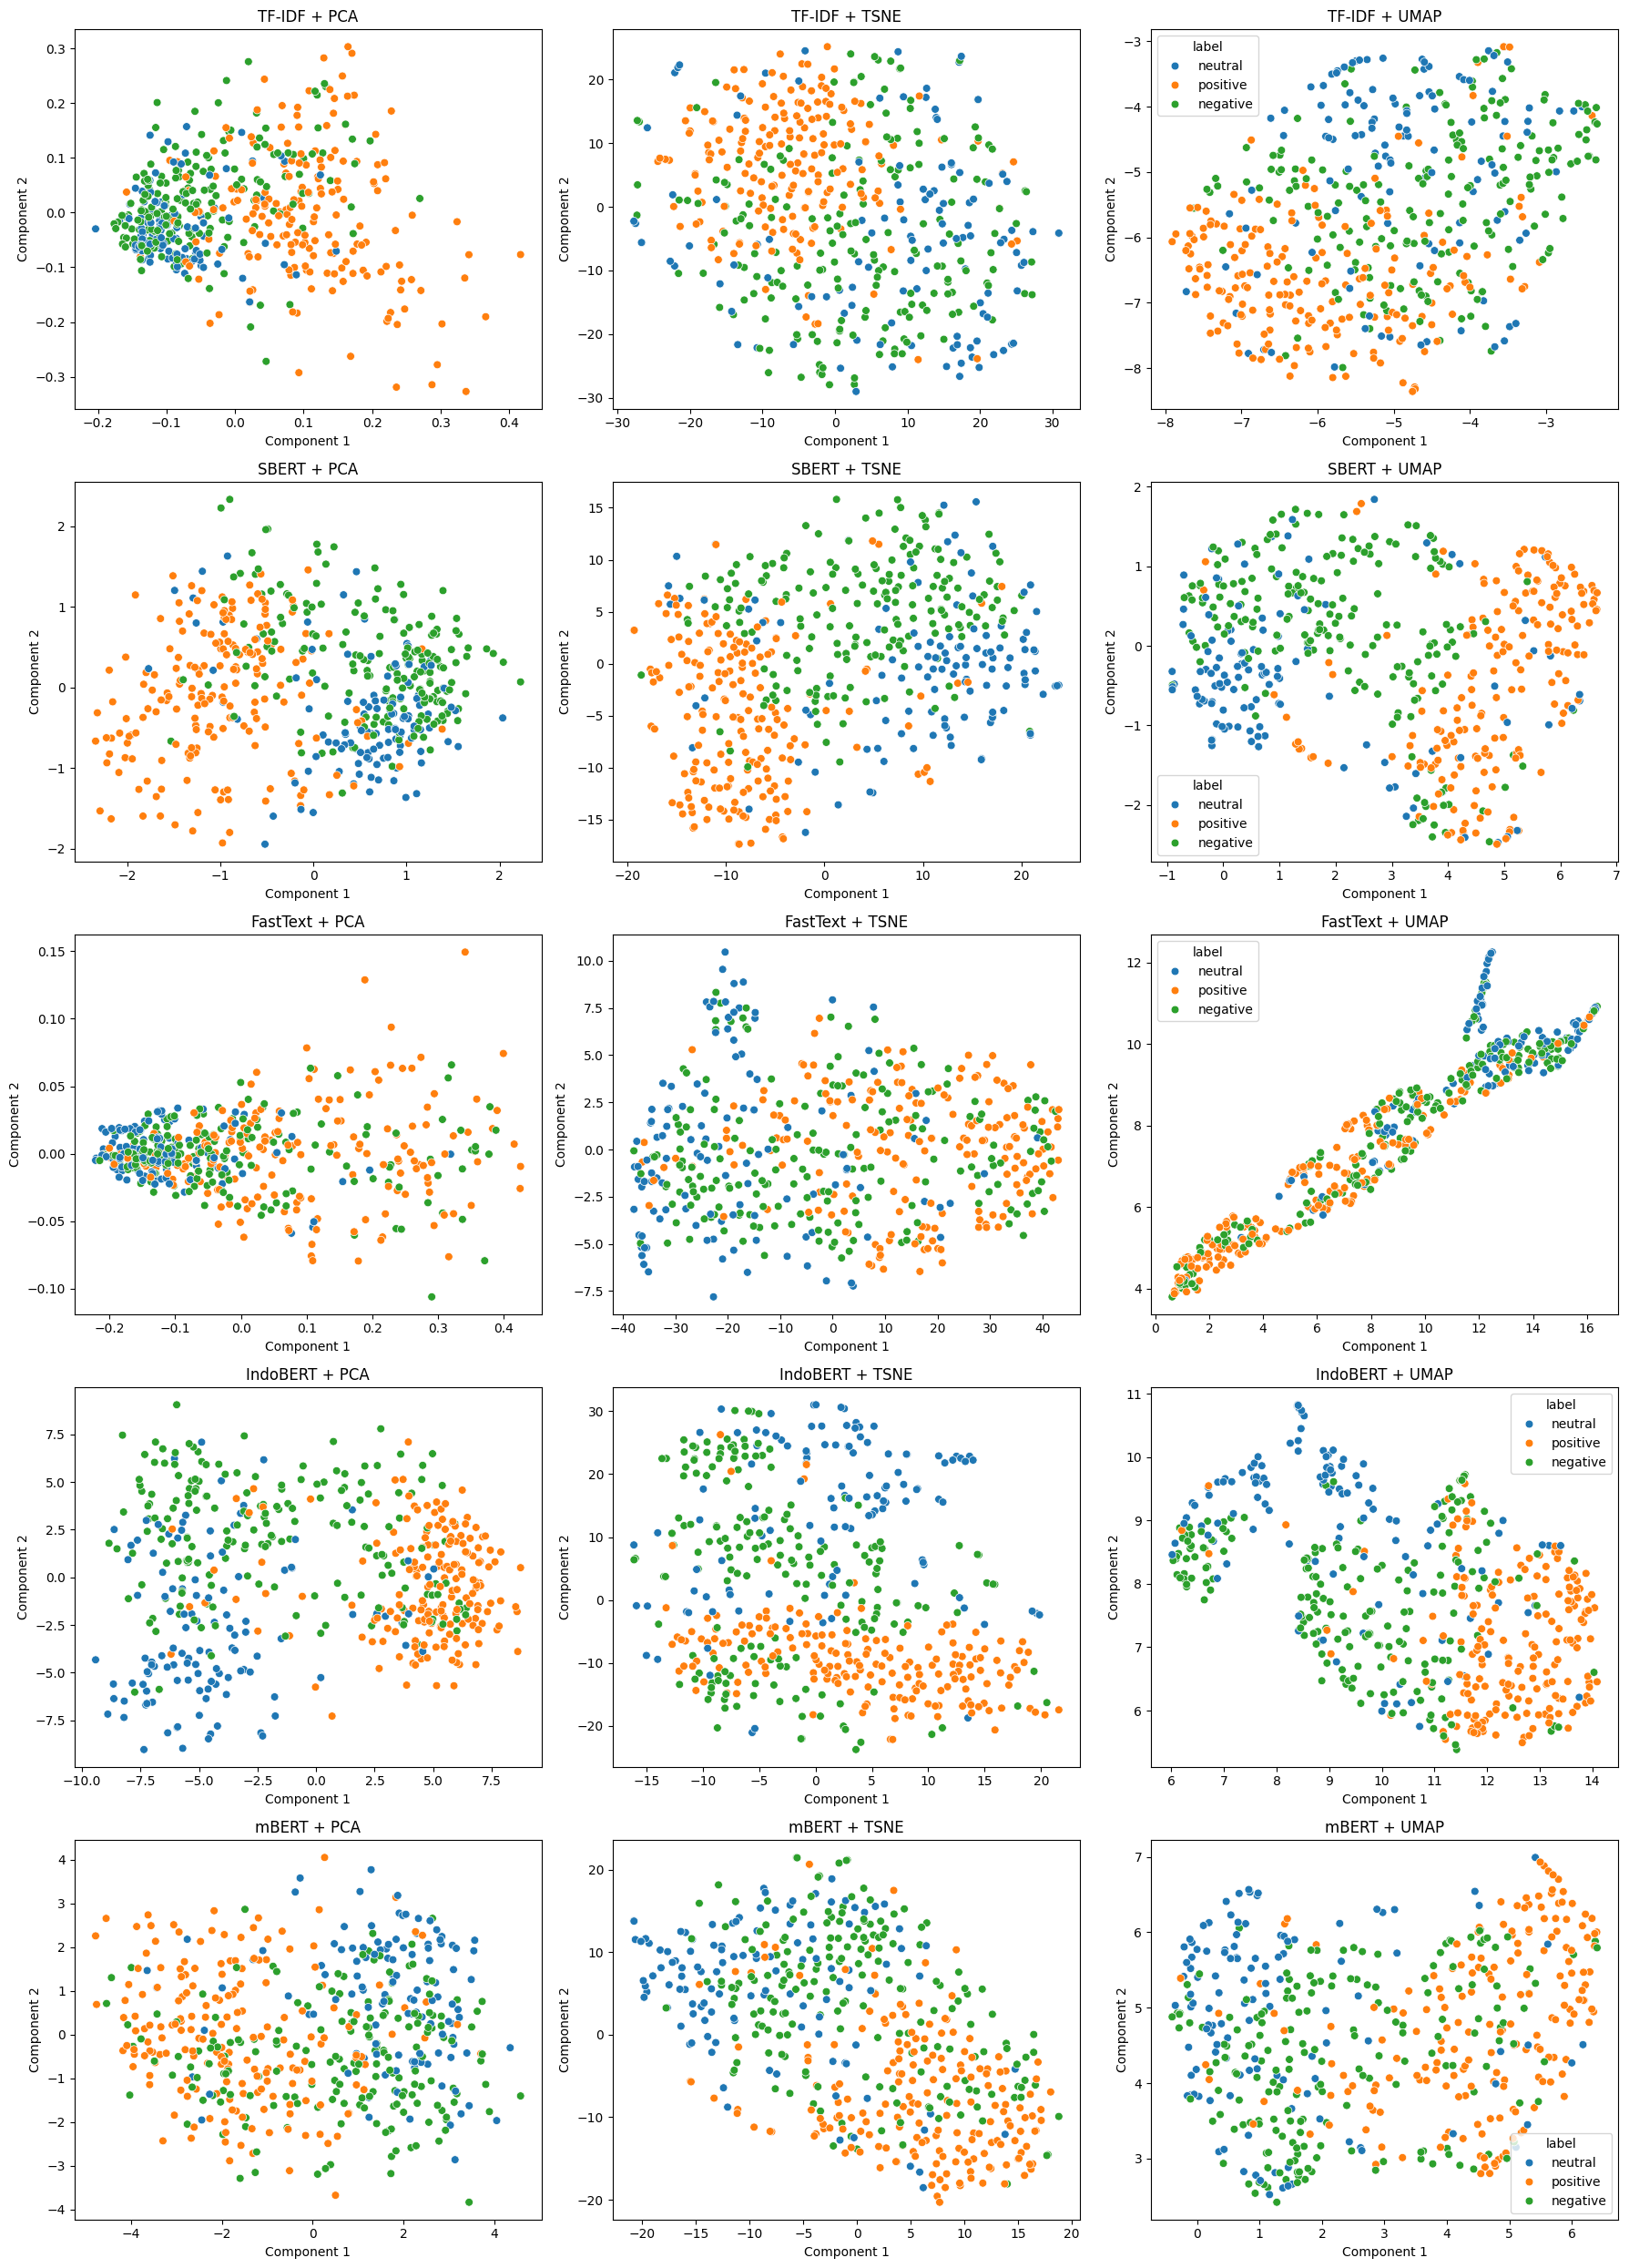

In [ ]:
embeddings_dict = {
    "TF-IDF": tfidf_embed,
    "SBERT": sbert_embed,
    "FastText": fasttext_embed,
    "IndoBERT": indobert_embed,
    "mBERT": mbert_embed
}

visualizer = EmbeddingComparisonVisualizer()

visualizer.plot_grid(embeddings_dict, df_train_clean['label'])

# **4. Model**

# **5. Evaluation**